In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from collections import Counter
import shap
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import make_scorer
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, auc
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
Data1 = pd.read_csv("football.csv")

In [3]:
Data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82821 entries, 0 to 82820
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   match_id           82821 non-null  int64  
 1   match_date         82821 non-null  object 
 2   competition_id     82821 non-null  int64  
 3   season_id          82821 non-null  int64  
 4   location           82821 non-null  object 
 5   under_pressure     82821 non-null  bool   
 6   event_id           82821 non-null  int64  
 7   stats_xg           82821 non-null  float64
 8   loc_end            82821 non-null  object 
 9   shot_outcome       82821 non-null  object 
 10  shot_type          82821 non-null  object 
 11  body_part          82821 non-null  object 
 12  competition_name   82821 non-null  object 
 13  season_name        82821 non-null  object 
 14  play_pattern_name  82821 non-null  object 
 15  team_name          82821 non-null  object 
 16  player_name        828

In [4]:
# Generate descriptive statistics for numerical columns
Data1.describe()

,match_id,competition_id,season_id,event_id,stats_xg,shot_distance,shot_angle,defence_density,x_list,y_list
count,8.282100e+04,82821.000000,82821.000000,82821.0,82821.000000,82821.000000,82815.000000,82821.000000,82821.000000,82821.000000
mean,2.921623e+06,63.869333,40.888084,16.0,0.105647,19.226970,25.357775,1.731469,103.554479,39.758011
std,1.582536e+06,233.637522,40.158029,0.0,0.147824,8.744127,15.829402,1.057190,8.794108,9.913994
min,7.298000e+03,2.000000,1.000000,16.0,0.000180,0.400000,0.000000,0.000000,30.800000,0.300000
25%,2.275105e+06,7.000000,27.000000,16.0,0.027616,12.044086,14.994696,1.000000,97.200000,32.400000
50%,3.817891e+06,11.000000,27.000000,16.0,0.054787,18.488916,19.663649,1.000000,105.000000,40.000000
75%,3.879720e+06,37.000000,40.000000,16.0,0.109881,25.570491,31.330685,2.000000,110.600000,47.000000
max,3.906390e+06,1470.000000,279.000000,16.0,0.995122,92.800862,180.000000,11.000000,120.500000,80.000000


In [3]:
# Filter data for specific competitions and reset index
Data2 = Data1[Data1["competition_name"].isin(["Women's World Cup", "Champions League",
                                  'La Liga', 'Ligue 1','Premier League','FIFA World Cup'])]
Data2 = Data2.reset_index(drop=True)

In [4]:
# Filter data for specific seasons and reset index
data3 = Data2[Data2["season_name"].isin([ '2010/2011', '2011/2012','2012/2013', '2013/2014',
       '2014/2015','2015/2016', '2016/2017', '2017/2018','2018','2018/2019','2019',
       '2019/2020', '2020', '2020/2021', '2021/2022', '2022', '2022/2023'
       ])].reset_index(drop=True)

In [5]:
data3["competition_name"].value_counts()

La Liga              17573
Ligue 1              10346
Premier League        9908
FIFA World Cup        3200
Women's World Cup     1314
Champions League       317
Name: competition_name, dtype: int64

In [6]:
# Less frequent "shot_type" are dropped and index reset
shot_drop = data3[data3["shot_type"].isin(["Open Play", "Free Kick"])]

data4 = shot_drop.reset_index(drop=True)

In [9]:
data4

,match_id,match_date,competition_id,season_id,location,under_pressure,event_id,stats_xg,loc_end,shot_outcome,...,team_name,player_name,position_name,shot_technique,shot_distance,shot_angle,frame_freezed_v2,defence_density,x_list,y_list
0,9880,2018-04-14,11,1,"[101.0, 21.3]",False,16,0.008752,"[117.0, 39.7, 1.6]",No Goal,...,Valencia,Gonçalo Manuel Ganchinho Guedes,Left Midfield,Normal,26.658770,12.341965,"[{'location': [95.6, 35.8], 'player': {'id': 5...",2,101.0,21.3
1,9880,2018-04-14,11,1,"[103.9, 28.4]",False,16,0.053915,"[105.9, 29.7]",No Goal,...,Valencia,Santiago Mina Lorenzo,Left Center Forward,Normal,19.843639,18.826717,"[{'location': [87.5, 30.1], 'player': {'id': 5...",1,103.9,28.4
2,9880,2018-04-14,11,1,"[112.5, 26.0]",False,16,0.080842,"[116.6, 34.0, 0.2]",No Goal,...,Barcelona,Jordi Alba Ramos,Left Back,Normal,15.882380,14.250033,"[{'location': [117.1, 34.0], 'player': {'id': ...",1,112.5,26.0
3,9880,2018-04-14,11,1,"[113.2, 46.0]",False,16,0.456472,"[120.0, 43.6, 0.2]",Goal,...,Barcelona,Luis Alberto Suárez Díaz,Left Center Forward,Normal,9.068627,39.394758,"[{'location': [104.5, 58.1], 'player': {'id': ...",1,113.2,46.0
4,9880,2018-04-14,11,1,"[92.8, 32.9]",False,16,0.025283,"[117.9, 36.3, 0.5]",No Goal,...,Valencia,Gonçalo Manuel Ganchinho Guedes,Left Midfield,Normal,28.111386,15.697815,"[{'location': [118.6, 38.5], 'player': {'id': ...",2,92.8,32.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42056,69161,2019-06-24,72,30,"[100.3, 52.5]",False,16,0.021892,"[101.1, 52.1]",No Goal,...,Spain Women's,Lucía García Córdoba,Right Midfield,Normal,23.331095,16.609461,"[{'location': [101.6, 52.0], 'player': {'id': ...",1,100.3,52.5
42057,69161,2019-06-24,72,30,"[96.3, 36.2]",False,16,0.038350,"[120.0, 39.1, 3.5]",No Goal,...,United States Women's,Rosemary Kathleen Lavelle,Right Center Midfield,Normal,24.002708,18.700592,"[{'location': [87.5, 56.0], 'player': {'id': 5...",3,96.3,36.2
42058,69161,2019-06-24,72,30,"[98.5, 24.3]",False,16,0.025679,"[120.0, 47.1, 1.4]",No Goal,...,United States Women's,Samantha June Mewis,Left Center Midfield,Normal,26.622171,13.943962,"[{'location': [104.9, 30.6], 'player': {'id': ...",1,98.5,24.3
42059,69161,2019-06-24,72,30,"[102.9, 54.6]",True,16,0.037896,"[120.0, 45.1, 5.2]",No Goal,...,Spain Women's,Lucía García Córdoba,Right Midfield,Half Volley,22.484884,15.611898,"[{'location': [79.2, 21.1], 'player': {'id': 4...",1,102.9,54.6


In [7]:
dl = data4[data4["competition_name"].isin(["Ligue 1"])
         ][data4[data4["competition_name"].isin(["Ligue 1"])]["season_name"].isin(['2015/2016'])]

In [8]:
dd = dl.index

In [9]:
data4.drop(dd, inplace = True)

In [13]:
data4

,match_id,match_date,competition_id,season_id,location,under_pressure,event_id,stats_xg,loc_end,shot_outcome,...,team_name,player_name,position_name,shot_technique,shot_distance,shot_angle,frame_freezed_v2,defence_density,x_list,y_list
0,9880,2018-04-14,11,1,"[101.0, 21.3]",False,16,0.008752,"[117.0, 39.7, 1.6]",No Goal,...,Valencia,Gonçalo Manuel Ganchinho Guedes,Left Midfield,Normal,26.658770,12.341965,"[{'location': [95.6, 35.8], 'player': {'id': 5...",2,101.0,21.3
1,9880,2018-04-14,11,1,"[103.9, 28.4]",False,16,0.053915,"[105.9, 29.7]",No Goal,...,Valencia,Santiago Mina Lorenzo,Left Center Forward,Normal,19.843639,18.826717,"[{'location': [87.5, 30.1], 'player': {'id': 5...",1,103.9,28.4
2,9880,2018-04-14,11,1,"[112.5, 26.0]",False,16,0.080842,"[116.6, 34.0, 0.2]",No Goal,...,Barcelona,Jordi Alba Ramos,Left Back,Normal,15.882380,14.250033,"[{'location': [117.1, 34.0], 'player': {'id': ...",1,112.5,26.0
3,9880,2018-04-14,11,1,"[113.2, 46.0]",False,16,0.456472,"[120.0, 43.6, 0.2]",Goal,...,Barcelona,Luis Alberto Suárez Díaz,Left Center Forward,Normal,9.068627,39.394758,"[{'location': [104.5, 58.1], 'player': {'id': ...",1,113.2,46.0
4,9880,2018-04-14,11,1,"[92.8, 32.9]",False,16,0.025283,"[117.9, 36.3, 0.5]",No Goal,...,Valencia,Gonçalo Manuel Ganchinho Guedes,Left Midfield,Normal,28.111386,15.697815,"[{'location': [118.6, 38.5], 'player': {'id': ...",2,92.8,32.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42056,69161,2019-06-24,72,30,"[100.3, 52.5]",False,16,0.021892,"[101.1, 52.1]",No Goal,...,Spain Women's,Lucía García Córdoba,Right Midfield,Normal,23.331095,16.609461,"[{'location': [101.6, 52.0], 'player': {'id': ...",1,100.3,52.5
42057,69161,2019-06-24,72,30,"[96.3, 36.2]",False,16,0.038350,"[120.0, 39.1, 3.5]",No Goal,...,United States Women's,Rosemary Kathleen Lavelle,Right Center Midfield,Normal,24.002708,18.700592,"[{'location': [87.5, 56.0], 'player': {'id': 5...",3,96.3,36.2
42058,69161,2019-06-24,72,30,"[98.5, 24.3]",False,16,0.025679,"[120.0, 47.1, 1.4]",No Goal,...,United States Women's,Samantha June Mewis,Left Center Midfield,Normal,26.622171,13.943962,"[{'location': [104.9, 30.6], 'player': {'id': ...",1,98.5,24.3
42059,69161,2019-06-24,72,30,"[102.9, 54.6]",True,16,0.037896,"[120.0, 45.1, 5.2]",No Goal,...,Spain Women's,Lucía García Córdoba,Right Midfield,Half Volley,22.484884,15.611898,"[{'location': [79.2, 21.1], 'player': {'id': 4...",1,102.9,54.6


In [10]:
gk_drop = list(data4[data4['position_name'] == 'Goalkeeper'].index)
data4.drop(gk_drop, inplace=True)

In [15]:
round(data4['shot_outcome'].value_counts(1)* 100, 2)

No Goal    89.35
Goal       10.65
Name: shot_outcome, dtype: float64

In [11]:
data4.reset_index(drop=True, inplace=True)

In [12]:
def correct_lwback(position):
    if 'Right Wing Back' in position:
        return 'RW Back'
    elif 'Left Wing Back' in position:
        return 'LW Back'
    else:
        return position

In [13]:
data4["position_name"] = data4["position_name"].apply(correct_lwback)

In [14]:
def categorize_position(position):
    if 'Forward' in position or 'Attacking Midfield' in position or 'Secondary Striker' in position or 'Left Wing' in position or 'Right Wing' in position:
        return 'attacker'
    elif 'Midfield' in position:
        return 'midfielder'
    elif 'Back' in position:
        return 'defender'
    else:
        return 'unknown'

In [15]:
data4["position_name"] = data4["position_name"].apply(categorize_position)

In [16]:
data41 = data4.copy()

In [22]:
data41

,match_id,match_date,competition_id,season_id,location,under_pressure,event_id,stats_xg,loc_end,shot_outcome,...,team_name,player_name,position_name,shot_technique,shot_distance,shot_angle,frame_freezed_v2,defence_density,x_list,y_list
0,9880,2018-04-14,11,1,"[101.0, 21.3]",False,16,0.008752,"[117.0, 39.7, 1.6]",No Goal,...,Valencia,Gonçalo Manuel Ganchinho Guedes,midfielder,Normal,26.658770,12.341965,"[{'location': [95.6, 35.8], 'player': {'id': 5...",2,101.0,21.3
1,9880,2018-04-14,11,1,"[103.9, 28.4]",False,16,0.053915,"[105.9, 29.7]",No Goal,...,Valencia,Santiago Mina Lorenzo,attacker,Normal,19.843639,18.826717,"[{'location': [87.5, 30.1], 'player': {'id': 5...",1,103.9,28.4
2,9880,2018-04-14,11,1,"[112.5, 26.0]",False,16,0.080842,"[116.6, 34.0, 0.2]",No Goal,...,Barcelona,Jordi Alba Ramos,defender,Normal,15.882380,14.250033,"[{'location': [117.1, 34.0], 'player': {'id': ...",1,112.5,26.0
3,9880,2018-04-14,11,1,"[113.2, 46.0]",False,16,0.456472,"[120.0, 43.6, 0.2]",Goal,...,Barcelona,Luis Alberto Suárez Díaz,attacker,Normal,9.068627,39.394758,"[{'location': [104.5, 58.1], 'player': {'id': ...",1,113.2,46.0
4,9880,2018-04-14,11,1,"[92.8, 32.9]",False,16,0.025283,"[117.9, 36.3, 0.5]",No Goal,...,Valencia,Gonçalo Manuel Ganchinho Guedes,midfielder,Normal,28.111386,15.697815,"[{'location': [118.6, 38.5], 'player': {'id': ...",2,92.8,32.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33332,69161,2019-06-24,72,30,"[100.3, 52.5]",False,16,0.021892,"[101.1, 52.1]",No Goal,...,Spain Women's,Lucía García Córdoba,midfielder,Normal,23.331095,16.609461,"[{'location': [101.6, 52.0], 'player': {'id': ...",1,100.3,52.5
33333,69161,2019-06-24,72,30,"[96.3, 36.2]",False,16,0.038350,"[120.0, 39.1, 3.5]",No Goal,...,United States Women's,Rosemary Kathleen Lavelle,midfielder,Normal,24.002708,18.700592,"[{'location': [87.5, 56.0], 'player': {'id': 5...",3,96.3,36.2
33334,69161,2019-06-24,72,30,"[98.5, 24.3]",False,16,0.025679,"[120.0, 47.1, 1.4]",No Goal,...,United States Women's,Samantha June Mewis,midfielder,Normal,26.622171,13.943962,"[{'location': [104.9, 30.6], 'player': {'id': ...",1,98.5,24.3
33335,69161,2019-06-24,72,30,"[102.9, 54.6]",True,16,0.037896,"[120.0, 45.1, 5.2]",No Goal,...,Spain Women's,Lucía García Córdoba,midfielder,Half Volley,22.484884,15.611898,"[{'location': [79.2, 21.1], 'player': {'id': 4...",1,102.9,54.6


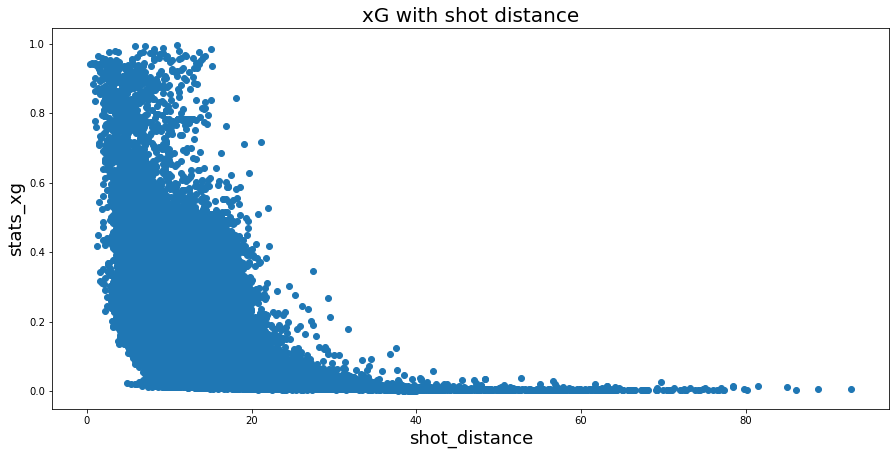

In [17]:
import matplotlib.pyplot as plt

# Sample data
y_values = Data1["stats_xg"]
x_values = Data1["shot_distance"]

plt.figure(figsize=(15, 7))

# Create a scatter plot
plt.scatter(x_values, y_values)


# Set the title and labels
plt.title('xG with shot distance', fontsize=20)
plt.xlabel('shot_distance', fontsize=18)
plt.ylabel('stats_xg', fontsize=18)

plt.savefig('xG with shot distance.jpg', bbox_inches='tight')

# Show the plot
plt.show()

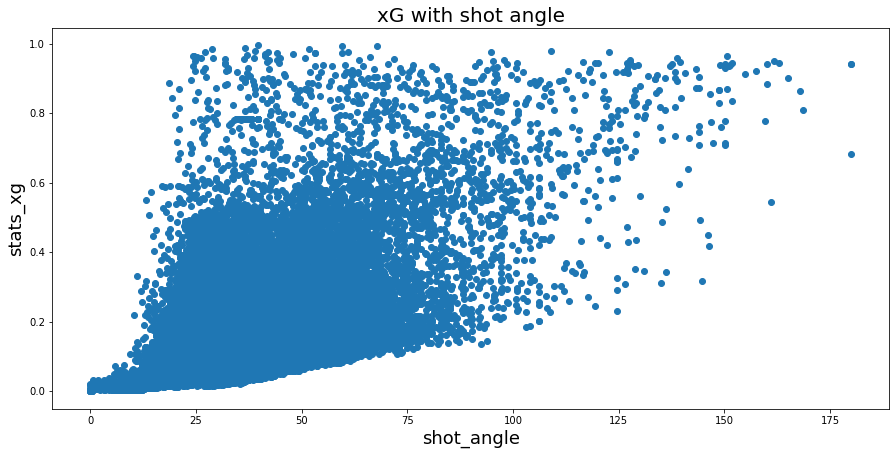

In [18]:
import matplotlib.pyplot as plt

# Sample data
y_values = Data1["stats_xg"]
x_values = Data1["shot_angle"]

plt.figure(figsize=(15, 7))

# Create a scatter plot
plt.scatter(x_values, y_values)


# Set the title and labels
plt.title('xG with shot angle', fontsize=20)
plt.xlabel('shot_angle', fontsize=18)
plt.ylabel('stats_xg', fontsize=18)

plt.savefig('xG with shot angle.jpg', bbox_inches='tight')

# Show the plot
plt.show()

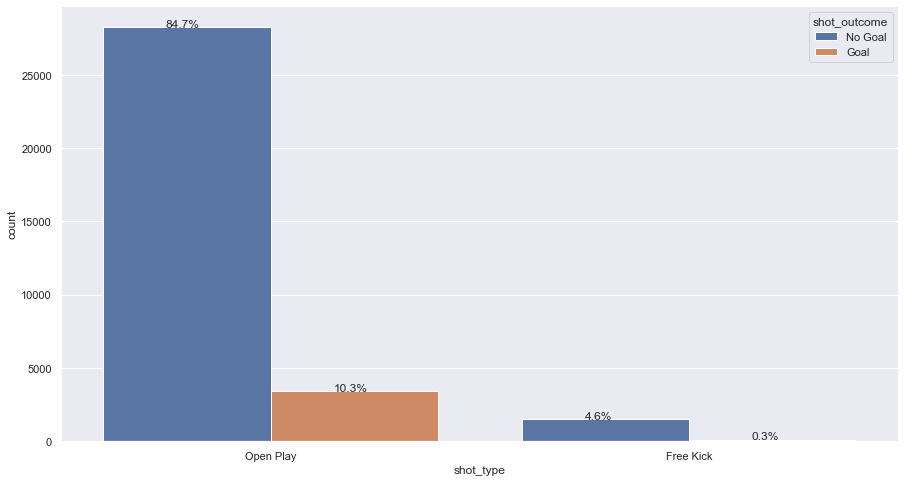

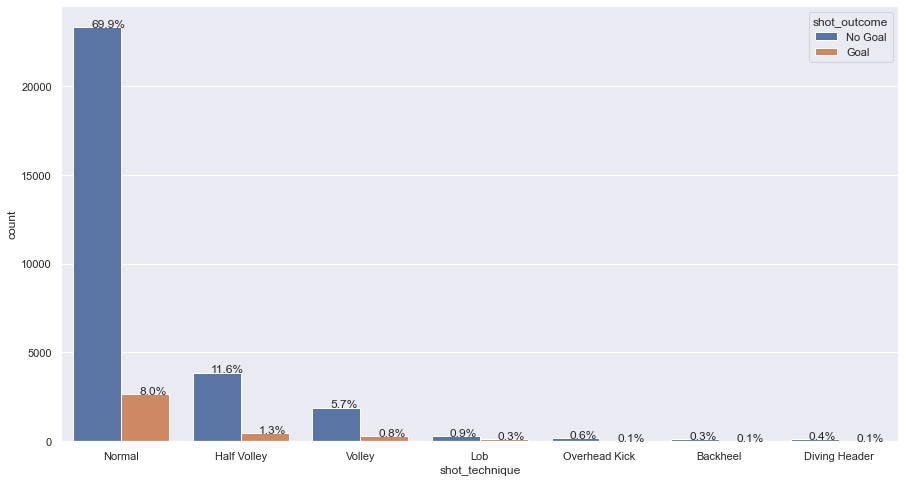

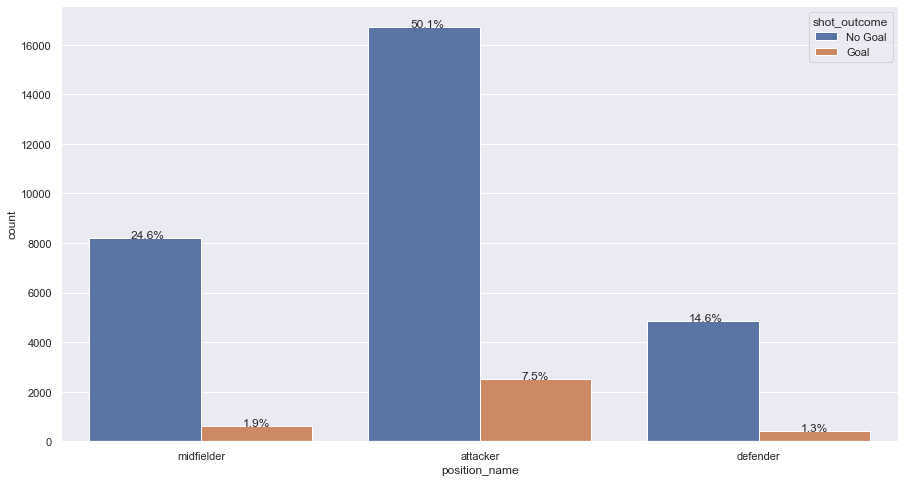

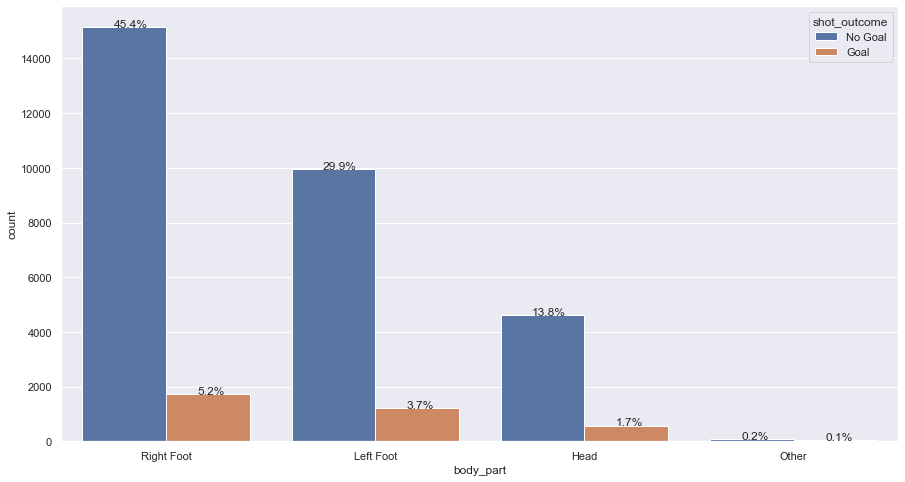

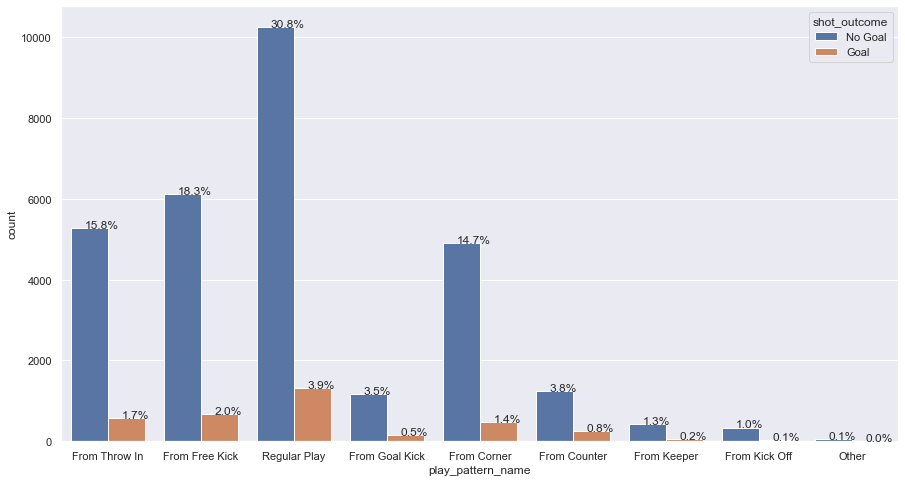

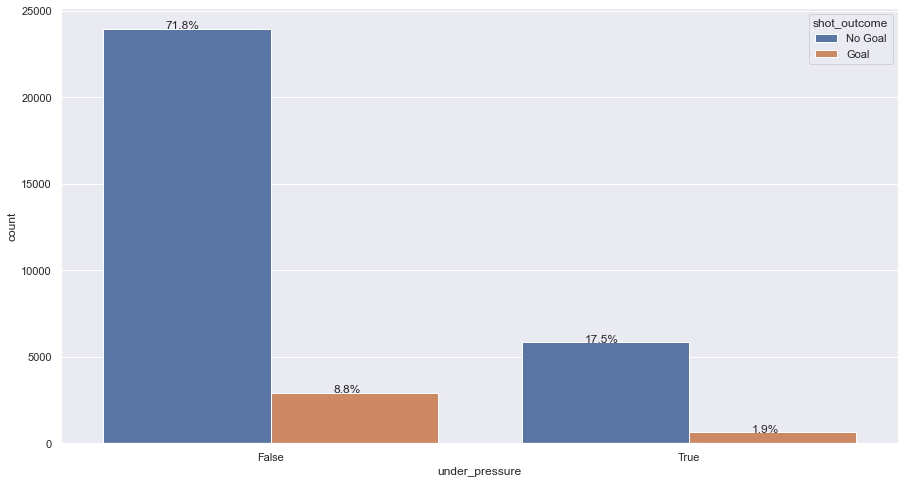

In [19]:
import seaborn as sns

categorical_vars = data41[['shot_type', 'shot_technique', 'position_name', 'body_part', 'play_pattern_name', 'under_pressure']]
categorical_vars = categorical_vars.columns 
sns.set_theme(rc={'figure.figsize':(15, 8)})
for var in categorical_vars:
    ay = sns.countplot(hue ='shot_outcome', x = var,  data = data41)
    total = float(len(data41))
    for p in ay.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width()/2 - 0.05
        y = p.get_y() + p.get_height()
        ay.annotate(percentage, (x, y), size=12)
    plt.show()

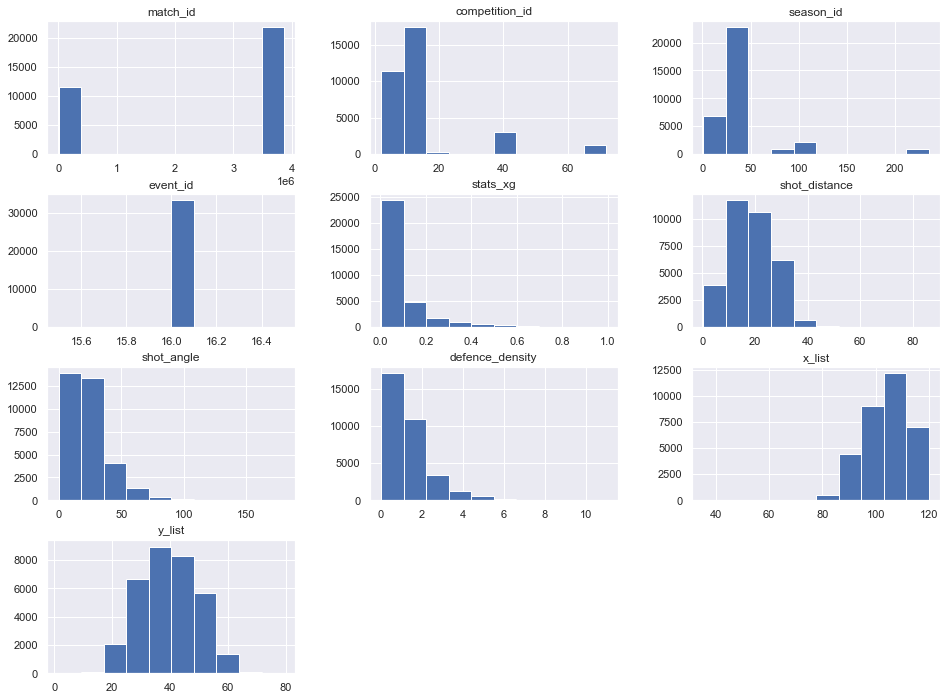

In [20]:
data41.select_dtypes(include='number').hist(figsize = (16, 12))

plt.savefig('num_cols.jpg', bbox_inches='tight')
plt.show()

In [21]:
def change_outcome(x):
    if "No Goal" in x:
        return 0
    elif "Goal" in x:
        return 1
    else:
        return x

In [22]:
data41['shot_outcome'] = data41['shot_outcome'].apply(change_outcome)

In [23]:
data41.corr()

,match_id,competition_id,season_id,under_pressure,event_id,stats_xg,shot_outcome,shot_distance,shot_angle,defence_density,x_list,y_list
match_id,1.000000,-0.412549,0.333180,0.040606,NaN,-0.023766,-0.029141,0.007180,0.006849,0.003283,-0.015873,0.003792
competition_id,-0.412549,1.000000,0.044022,-0.015394,NaN,-0.007784,-0.007271,-0.005892,0.018383,0.016526,0.007530,0.009945
season_id,0.333180,0.044022,1.000000,0.002866,NaN,0.018056,0.007374,-0.025717,0.010794,-0.006190,0.020315,-0.012441
under_pressure,0.040606,-0.015394,0.002866,1.000000,NaN,-0.017968,-0.015329,-0.221269,0.197407,-0.068147,0.196249,0.011460
event_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stats_xg,-0.023766,-0.007784,0.018056,-0.017968,NaN,1.000000,0.437357,-0.559608,0.692510,-0.320208,0.468178,0.010693
shot_outcome,-0.029141,-0.007271,0.007374,-0.015329,NaN,0.437357,1.000000,-0.247448,0.298867,-0.145499,0.208868,0.001351
shot_distance,0.007180,-0.005892,-0.025717,-0.221269,NaN,-0.559608,-0.247448,1.000000,-0.741335,0.235957,-0.937567,-0.015547
shot_angle,0.006849,0.018383,0.010794,0.197407,NaN,0.692510,0.298867,-0.741335,1.000000,-0.151914,0.576598,0.018780
defence_density,0.003283,0.016526,-0.006190,-0.068147,NaN,-0.320208,-0.145499,0.235957,-0.151914,1.000000,-0.301079,-0.001777


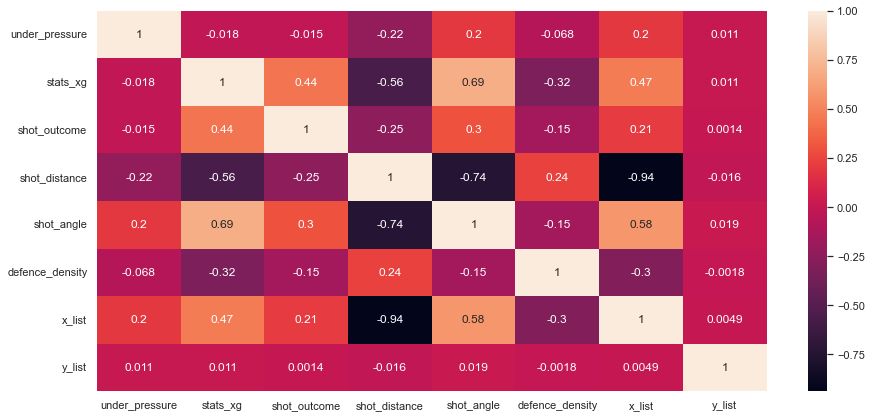

In [24]:
plt.figure(figsize = (15, 7))
sns.heatmap(data = data41.drop(['match_id', 'competition_id', 'season_id', 'event_id'], axis = 1).corr(), annot = True)
plt.savefig('correlation.jpg', bbox_inches='tight')
plt.show()

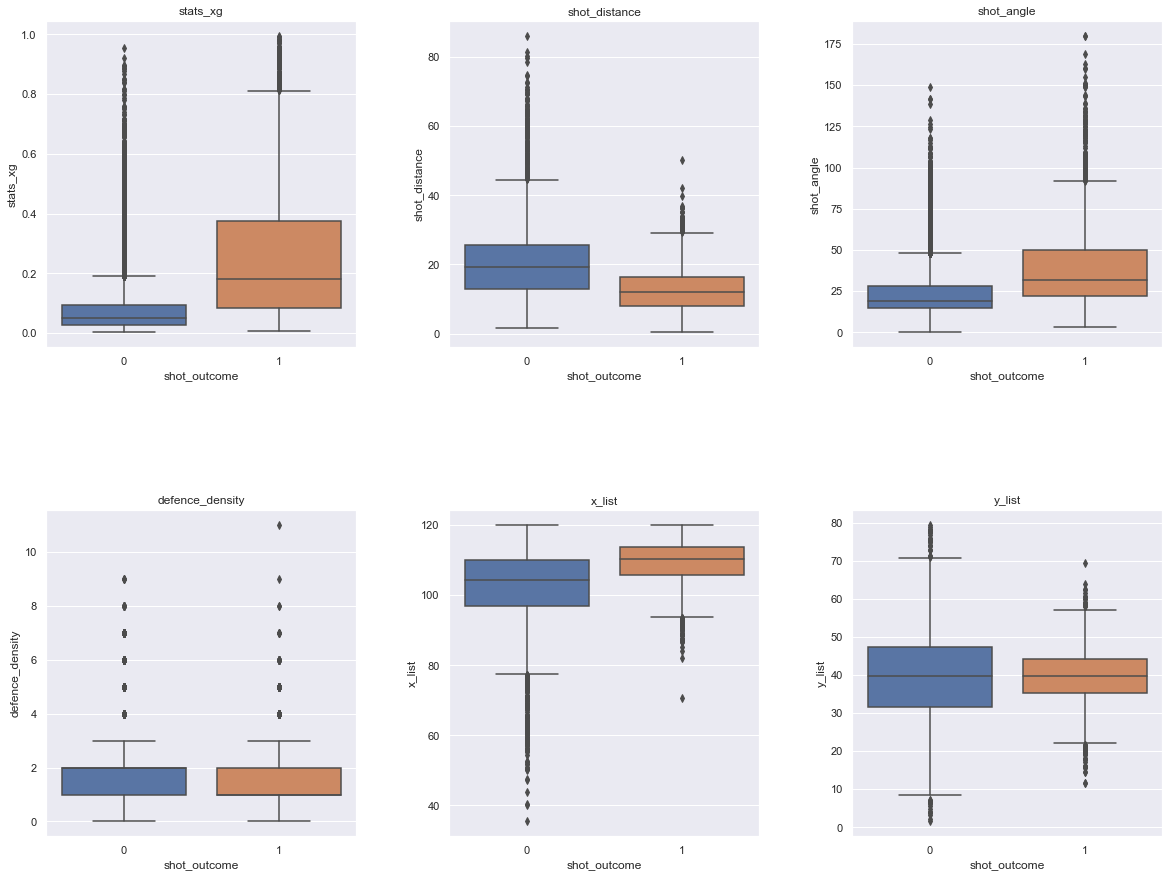

In [25]:
import math
numerical_vars = [var for var in data41.select_dtypes(include='number').columns]
columns_to_remove = ['shot_outcome', 'match_id', 'competition_id', 'season_id', 'event_id']

# Remove specified columns from numerical_vars
numerical_vars = [var for var in numerical_vars if var not in columns_to_remove]

n_cols = min(3, len(numerical_vars))
n_rows = math.ceil(len(numerical_vars) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
fig.subplots_adjust(hspace=0.5, wspace=0.3)

for i, num in enumerate(numerical_vars):
    row_idx = i // n_cols
    col_idx = i % n_cols
    try:
        ax = axes[row_idx, col_idx]
        sns.boxplot(data=data41, y=num, x='shot_outcome', ax=ax)
        ax.set(title=num)
    except IndexError:
        break

plt.show()

In [32]:
data41.groupby('shot_outcome').mean().style.format("{:,.0f}")

,match_id,competition_id,season_id,under_pressure,event_id,stats_xg,shot_distance,shot_angle,defence_density,x_list,y_list
shot_outcome,,,,,,,,,,,
0,"2,542,889",14,36,0,16,0,20,24,2,103,40
1,"2,377,648",13,36,0,16,0,13,39,1,109,40


In [33]:
data41.groupby('shot_outcome').median().style.format("{:,.0f}")

,match_id,competition_id,season_id,under_pressure,event_id,stats_xg,shot_distance,shot_angle,defence_density,x_list,y_list
shot_outcome,,,,,,,,,,,
0,"3,754,178",11,27,0,16,0,19,19,2,104,40
1,"3,754,137",11,27,0,16,0,12,32,1,110,40


In [26]:
normal = data4[['competition_name', 'season_name','shot_outcome', 'shot_type','body_part','shot_distance','shot_angle', 'stats_xg']]
advance = data4[['competition_name', 'season_name', 'shot_outcome', 'shot_type', 'body_part', 'shot_technique', 'position_name',
                    'shot_distance','shot_angle', 'defence_density', 'stats_xg']]

In [27]:
normal.isnull().sum()

competition_name    0
season_name         0
shot_outcome        0
shot_type           0
body_part           0
shot_distance       0
shot_angle          1
stats_xg            0
dtype: int64

In [28]:
advance.isnull().sum()

competition_name    0
season_name         0
shot_outcome        0
shot_type           0
body_part           0
shot_technique      0
position_name       0
shot_distance       0
shot_angle          1
defence_density     0
stats_xg            0
dtype: int64

In [29]:
normal.dropna(inplace=True)

C:\Users\Wales\anaconda3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [30]:
advance.dropna(inplace=True)

In [31]:
normal.reset_index(drop=True)

,competition_name,season_name,shot_outcome,shot_type,body_part,shot_distance,shot_angle,stats_xg
0,La Liga,2017/2018,No Goal,Open Play,Right Foot,26.658770,12.341965,0.008752
1,La Liga,2017/2018,No Goal,Open Play,Right Foot,19.843639,18.826717,0.053915
2,La Liga,2017/2018,No Goal,Open Play,Left Foot,15.882380,14.250033,0.080842
3,La Liga,2017/2018,Goal,Open Play,Right Foot,9.068627,39.394758,0.456472
4,La Liga,2017/2018,No Goal,Open Play,Right Foot,28.111386,15.697815,0.025283
...,...,...,...,...,...,...,...,...
33331,Women's World Cup,2019,No Goal,Open Play,Right Foot,23.331095,16.609461,0.021892
33332,Women's World Cup,2019,No Goal,Open Play,Left Foot,24.002708,18.700592,0.038350
33333,Women's World Cup,2019,No Goal,Open Play,Right Foot,26.622171,13.943962,0.025679
33334,Women's World Cup,2019,No Goal,Open Play,Right Foot,22.484884,15.611898,0.037896


In [32]:
advance.reset_index(drop=True)

,competition_name,season_name,shot_outcome,shot_type,body_part,shot_technique,position_name,shot_distance,shot_angle,defence_density,stats_xg
0,La Liga,2017/2018,No Goal,Open Play,Right Foot,Normal,midfielder,26.658770,12.341965,2,0.008752
1,La Liga,2017/2018,No Goal,Open Play,Right Foot,Normal,attacker,19.843639,18.826717,1,0.053915
2,La Liga,2017/2018,No Goal,Open Play,Left Foot,Normal,defender,15.882380,14.250033,1,0.080842
3,La Liga,2017/2018,Goal,Open Play,Right Foot,Normal,attacker,9.068627,39.394758,1,0.456472
4,La Liga,2017/2018,No Goal,Open Play,Right Foot,Normal,midfielder,28.111386,15.697815,2,0.025283
...,...,...,...,...,...,...,...,...,...,...,...
33331,Women's World Cup,2019,No Goal,Open Play,Right Foot,Normal,midfielder,23.331095,16.609461,1,0.021892
33332,Women's World Cup,2019,No Goal,Open Play,Left Foot,Normal,midfielder,24.002708,18.700592,3,0.038350
33333,Women's World Cup,2019,No Goal,Open Play,Right Foot,Normal,midfielder,26.622171,13.943962,1,0.025679
33334,Women's World Cup,2019,No Goal,Open Play,Right Foot,Half Volley,midfielder,22.484884,15.611898,1,0.037896


In [33]:
advance["position_name"].unique()

array(['midfielder', 'attacker', 'defender'], dtype=object)

In [34]:
norm_val = normal[normal["competition_name"].isin(["La Liga", "Women's World Cup", "FIFA World Cup"])]
norm_val = norm_val[norm_val["season_name"].isin(["2020/2021","2022", "2019"])]

In [35]:
dat5 = norm_val.index

In [36]:
normal1 = normal.drop(dat5)
normal1.reset_index(drop=True, inplace=True)

In [37]:
normal1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29803 entries, 0 to 29802
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   competition_name  29803 non-null  object 
 1   season_name       29803 non-null  object 
 2   shot_outcome      29803 non-null  object 
 3   shot_type         29803 non-null  object 
 4   body_part         29803 non-null  object 
 5   shot_distance     29803 non-null  float64
 6   shot_angle        29803 non-null  float64
 7   stats_xg          29803 non-null  float64
dtypes: float64(3), object(5)
memory usage: 1.8+ MB


In [38]:
adva_val = advance[advance["competition_name"].isin(["La Liga", "Women's World Cup", "FIFA World Cup"])]
adva_val = adva_val[adva_val["season_name"].isin(["2020/2021", "2022","2019"])]

In [39]:
dat6 = adva_val.index

In [40]:
advance1 = advance.drop(dat6)
advance1.reset_index(drop=True, inplace=True)

In [41]:
advance1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29803 entries, 0 to 29802
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   competition_name  29803 non-null  object 
 1   season_name       29803 non-null  object 
 2   shot_outcome      29803 non-null  object 
 3   shot_type         29803 non-null  object 
 4   body_part         29803 non-null  object 
 5   shot_technique    29803 non-null  object 
 6   position_name     29803 non-null  object 
 7   shot_distance     29803 non-null  float64
 8   shot_angle        29803 non-null  float64
 9   defence_density   29803 non-null  int64  
 10  stats_xg          29803 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 2.5+ MB


In [42]:
def get_x_y(data_name, cols, num_cols, cat_cols):
    #grab the independent features using the provided columns 
    X = data_name[cols]
    #Set the target variable
    y = data_name["shot_outcome"]
    #create dataframe of categorical features
    X_categ = X[cat_cols]
    #Create a dataframe of numerical features
    X_numerical = X[num_cols]
    
    #Transform the categorical features
    encode = OneHotEncoder(sparse=False, handle_unknown="ignore")
    encode.fit(X_categ)
    X_array = encode.transform(X_categ)

    #Create a new DataFrame combining the encoded categorical columns and the numerical columns
    encoded_train_data = pd.DataFrame(X_array, columns=encode.get_feature_names_out(cat_cols))
    encoded_train_data[X_numerical.columns] = X_numerical
    
    #Using a robust scaler, scale the independent features
    scale_data = RobustScaler()
    x = scale_data.fit_transform(encoded_train_data)
    
    return x, y, encoded_train_data

In [43]:
y_class = {"No Goal":0, "Goal":1}

In [44]:
columns = ['shot_type','body_part','shot_distance','shot_angle']
categorical = columns[:2]
numerical = columns[2:]

In [45]:
X_norm, y_norm, normt_data = get_x_y(normal1, columns, numerical, categorical)

C:\Users\Wales\anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [46]:
norm_val.reset_index(drop=True, inplace=True)

In [47]:
x_val, y_val, normv_data = get_x_y(norm_val, columns, numerical, categorical)

C:\Users\Wales\anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [48]:
y_val = y_val.map(y_class)

In [49]:
y = y_norm.map(y_class)

In [50]:
xnorm_train, xnorm_test, ynorm_train, ynorm_test = train_test_split(X_norm, y, test_size=0.3, random_state=0, stratify=y)

In [51]:
LR_norm = LogisticRegression(random_state=1)
LR_norm.fit(xnorm_train, ynorm_train)

LogisticRegression(random_state=1)

In [52]:
estimators = [('LR', LogisticRegression()),
              ('RF', RandomForestClassifier()), 
              ('DT', DecisionTreeClassifier()),
              ('XGB', XGBClassifier())]
param_grid = {
              'log_params':{
                 'solver' : ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga']},
             'rand_params':{
                 'n_estimators':[100, 200, 500, 1000],
                 'criterion':["gini", "entropy", "log_loss"]},
              'dec_params':{
                  'criterion':["gini", "entropy", "log_loss"],
                  'splitter' : ["best", "random"]},
              'xgb_params':{
#                   'max_depth': [2, 4, 6],
#                   'learning_rate': [0.1, 0.01, 0.05]}}
                  'max_depth': range(2, 10, 1),
                  'n_estimators': range(60, 220, 40),
                  'learning_rate': [0.1, 0.01, 0.05]}}
scoring_param = make_scorer(log_loss, greater_is_better=False, needs_proba=True)
for index, param_tuple in enumerate(param_grid.items()):
    grid_model = GridSearchCV(estimators[0:4][index][1], param_tuple[1], cv=5, scoring=scoring_param, n_jobs=-1)
    grid_model.fit(xnorm_train, ynorm_train)
    
    print("Best parameters: {}".format(grid_model.best_params_))
    print("Best cross-validation score: {:.2f}".format(grid_model.best_score_))

Best parameters: {'solver': 'sag'}
Best cross-validation score: -0.29
Best parameters: {'criterion': 'gini', 'n_estimators': 1000}
Best cross-validation score: -0.52
Best parameters: {'criterion': 'entropy', 'splitter': 'best'}
Best cross-validation score: -5.57
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 60}
Best cross-validation score: -0.29


In [61]:
scoring_param = make_scorer(log_loss, greater_is_better=False, needs_proba=True)
estimators = [('LR', LogisticRegression(solver = 'saga')),
              ('RF', RandomForestClassifier(criterion = 'log_loss', n_estimators= 1000 )), 
              ('DT', DecisionTreeClassifier(criterion = 'entropy', splitter = 'best')),
              ('XGB', XGBClassifier(learning_rate = 0.1, max_depth = 3, n_estimators = 60))]
for name, estimator in estimators:
    scores = cross_val_score(estimator, xnorm_train, ynorm_train, cv=5, scoring=scoring_param)
    avg = -scores.mean()
    print("Average Cross Val Score for {} is {:.3f}".format(name, avg))

Average Cross Val Score for LR is 0.288
Average Cross Val Score for RF is 0.541
Average Cross Val Score for DT is 5.572
Average Cross Val Score for XGB is 0.288


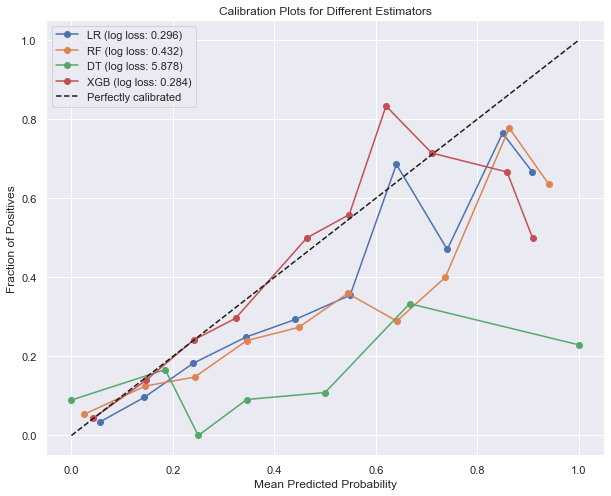

In [62]:
plt.figure(figsize=(10, 8))

for name, clf in estimators:
    # Train the classifier
    clf.fit(xnorm_train, ynorm_train)
    
    pred_norm = clf.predict_proba(x_val)[:, 1]

    # Compute calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(y_val, pred_norm, n_bins=10)

    # Compute Brier score
    loss = log_loss(y_val, pred_norm)

    # Plot calibration curve
    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=f'{name} (log loss: {loss:.3f})')

# Plot the diagonal (perfectly calibrated curve)
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.title('Calibration Plots for Different Estimators')
plt.show()

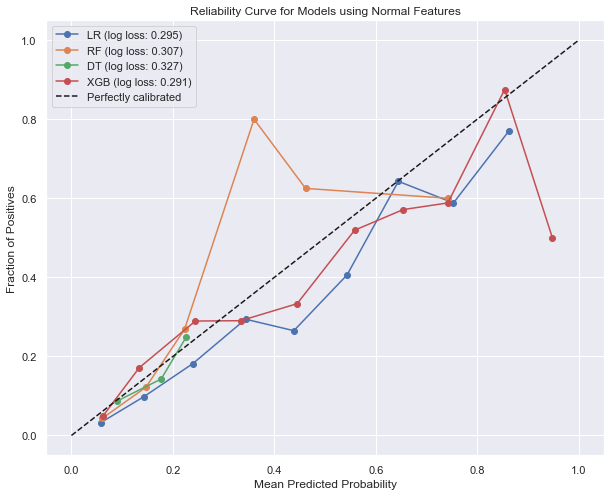

In [64]:
plt.figure(figsize=(10, 8))

for name, clf in estimators:
    # Train the classifier
    clf.fit(xnorm_train, ynorm_train)
    
    if name == "DT" or name == "RF":
        cal_model = CalibratedClassifierCV(clf, cv='prefit', method='isotonic')
    else:
        cal_model = CalibratedClassifierCV(clf, cv='prefit', method='sigmoid')

    cal_model.fit(xnorm_test, ynorm_test)
    
    cal_prob = cal_model.predict_proba(x_val)[:,1]

    # Compute calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(y_val, cal_prob, n_bins=10)

    # Compute Brier score
    loss = log_loss(y_val, cal_prob)

    # Plot calibration curve
    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=f'{name} (log loss: {loss:.3f})')

# Plot the diagonal (perfectly calibrated curve)
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.title('Reliability Curve for Models using Normal Features')
plt.savefig('nornal_reliability curve.jpg', bbox_inches='tight')
plt.show()

In [63]:
cols = ['shot_type','body_part', 'shot_technique', 'position_name', 'shot_distance','shot_angle', 'defence_density']
categorical = cols[:4]
numerical = cols[4:]
x_adv, y_adv, advt_data = get_x_y(advance1, cols, numerical, categorical)

C:\Users\Wales\anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [64]:
y_adv = y_adv.map(y_class)

In [65]:
xtrain_adv, xtest_adv, ytrain_adv, ytest_adv = train_test_split(x_adv, y_adv, test_size=0.3, random_state=0, stratify=y_adv)

In [66]:
adva_val.reset_index(drop=True, inplace=True)

In [67]:
xval_adv, yval_adv, adv_data = get_x_y(adva_val, cols, numerical, categorical)

C:\Users\Wales\anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [68]:
scoring_param1 = make_scorer(log_loss, greater_is_better=False, needs_proba=True)
estimators1 = [('LR1', LogisticRegression()),
              ('RF1', RandomForestClassifier()), 
              ('DT1', DecisionTreeClassifier()),
              ('XGB1', XGBClassifier())]
param_grid1 = {
              'log_params':{
                 'solver' : ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga']},
             'rand_params':{
                 'n_estimators':[100, 200, 500, 1000],
                 'criterion':["gini", "entropy", "log_loss"]},
              'dec_params':{
                  'criterion':["gini", "entropy", "log_loss"],
                  'splitter' : ["best", "random"]},
              'xgb_params':{
                  'max_depth': range(2, 10, 1),
                  'n_estimators': range(60, 220, 40),
                  'learning_rate': [0.1, 0.01, 0.05]}}
for index, param_tuple in enumerate(param_grid1.items()):
    grid_model1 = GridSearchCV(estimators1[0:4][index][1], param_tuple[1], cv=5, scoring=scoring_param1, n_jobs=-1)
    grid_model1.fit(xtrain_adv, ytrain_adv)
    
    print("Best parameters: {}".format(grid_model1.best_params_))
    print("Best cross-validation score: {:.2f}".format(grid_model1.best_score_))

Best parameters: {'solver': 'liblinear'}
Best cross-validation score: -0.28
Best parameters: {'criterion': 'gini', 'n_estimators': 1000}
Best cross-validation score: -0.42
Best parameters: {'criterion': 'log_loss', 'splitter': 'random'}
Best cross-validation score: -5.75
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best cross-validation score: -0.28


In [69]:
estimators1 = [('LR1', LogisticRegression(solver = 'liblinear', random_state = 1)),
              ('RF1', RandomForestClassifier(criterion = 'log_loss', n_estimators = 1000, random_state = 1)), 
              ('DT1', DecisionTreeClassifier(criterion = 'entropy', splitter = 'random', random_state = 1)),
              ('XGB1', XGBClassifier(max_depth = 3, learning_rate = 0.1, n_estimators = 100, random_state=1))]
scoring_param1 = make_scorer(log_loss, greater_is_better=False, needs_proba=True)

for name, estimator in estimators1:
    scores1 = cross_val_score(estimator, xtrain_adv, ytrain_adv, cv=5, scoring=scoring_param1)
    avg1 = -scores1.mean()
    print("Average Cross Val Score for {} is {:.3f}".format(name, avg1))

Average Cross Val Score for LR1 is 0.280
Average Cross Val Score for RF1 is 0.420
Average Cross Val Score for DT1 is 5.893
Average Cross Val Score for XGB1 is 0.277


In [70]:
yval_adv=yval_adv.map(y_class)

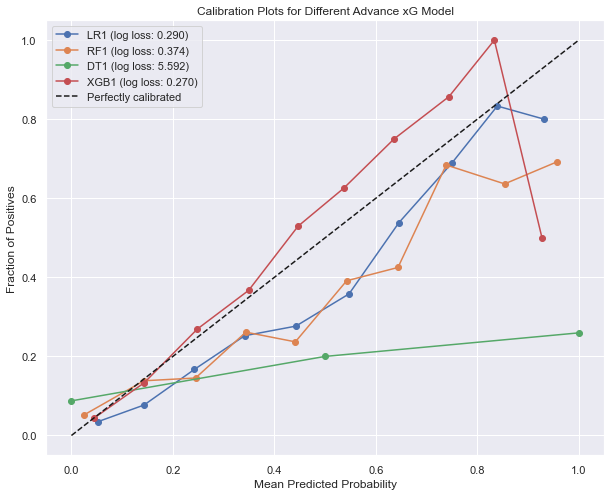

In [71]:
plt.figure(figsize=(10, 8))

for name, clf in estimators1:
    # Train the classifier
    clf.fit(xtrain_adv, ytrain_adv)
    
    pred_adv = clf.predict_proba(xval_adv)[:, 1]

    # Compute calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(yval_adv, pred_adv, n_bins=10)

    # Compute Brier score
    loss = log_loss(yval_adv, pred_adv)

    # Plot calibration curve
    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=f'{name} (log loss: {loss:.3f})')

# Plot the diagonal (perfectly calibrated curve)
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.title('Calibration Plots for Different Advance xG Model')
plt.show()

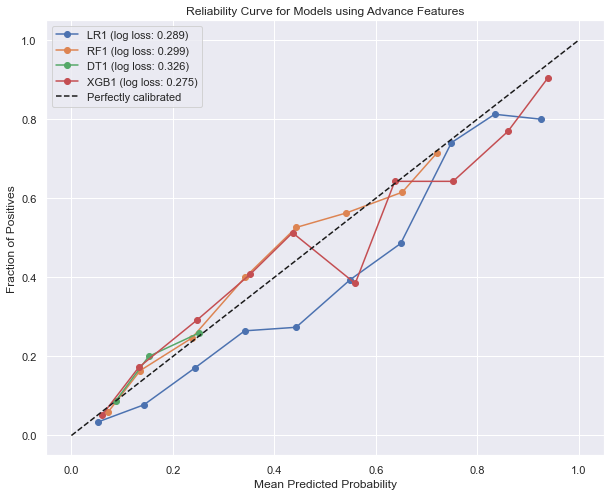

In [72]:
plt.figure(figsize=(10, 8))

for name, clf in estimators1:
    # Train the classifier
    clf.fit(xtrain_adv, ytrain_adv)
    
    if name == "DT" or name =="RF":
        cal_model = CalibratedClassifierCV(clf, cv='prefit', method='isotonic')
    else:
        cal_model = CalibratedClassifierCV(clf, cv='prefit', method='sigmoid')

    cal_model.fit(xtest_adv, ytest_adv)
    
    cal_prob_adv = cal_model.predict_proba(xval_adv)[:,1]

    # Compute calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(yval_adv, cal_prob_adv, n_bins=10)

    # Compute Log loss score
    loss = log_loss(yval_adv, cal_prob_adv)

    # Plot calibration curve
    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=f'{name} (log loss: {loss:.3f})')

# Plot the diagonal (perfectly calibrated curve)
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.title('Reliability Curve for Models using Advance Features')
plt.savefig('advance_reliability curve.jpg', bbox_inches='tight')
plt.show()

In [73]:
log_model = LogisticRegression(solver = 'liblinear', random_state = 1)
log_model.fit(x_adv, y_adv)

lodel_pred = log_model.predict_proba(xval_adv)[:,1]

In [74]:
log_loss(yval_adv, lodel_pred)

0.29016999393162607

In [75]:
xg_model = XGBClassifier(max_depth = 3, learning_rate = 0.1, n_estimators = 100, random_state=1)
xg_model.fit(x_adv, y_adv)

xodel_pred = xg_model.predict_proba(xval_adv)[:,1]

In [76]:
log_loss(yval_adv, xodel_pred)

0.27011625333937234

In [77]:
pd.DataFrame.from_dict(
    {"Stats xG": adva_val["stats_xg"],
     "LR xG": lodel_pred}).corr()

,Stats xG,LR xG
Stats xG,1.000000,0.856348
LR xG,0.856348,1.000000


In [78]:
pd.DataFrame.from_dict(
    {"Stats xG": adva_val["stats_xg"],
     "LR xG": xodel_pred}).corr()

,Stats xG,LR xG
Stats xG,1.000000,0.899946
LR xG,0.899946,1.000000


In [79]:
train_pred = log_model.predict_proba(x_adv)[:,1]

In [80]:
log_loss(y_adv, train_pred)

0.27949235839476627

In [81]:
XGtrain_pred = xg_model.predict_proba(x_adv)[:,1]

In [82]:
log_loss(y_adv, XGtrain_pred)

0.270130642346201

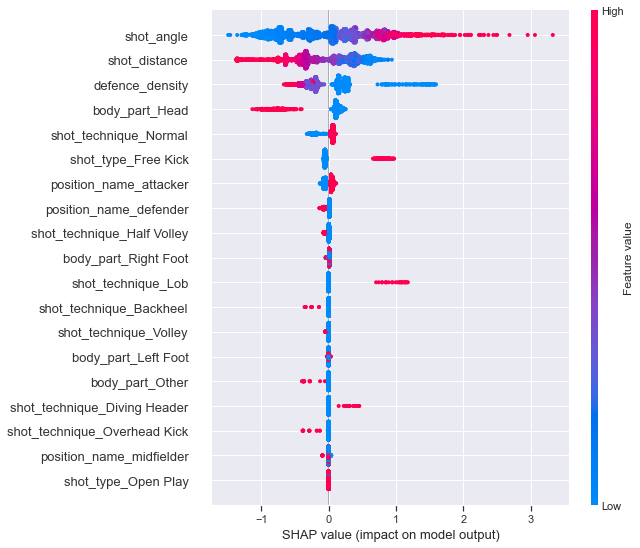

<Figure size 1080x576 with 0 Axes>

In [83]:
import shap
explainer = shap.Explainer(xg_model, x_adv, feature_names=adv_data.columns)
# Assuming X_test[0] is the specific instance for which you want to explain the prediction
shap_values = explainer(xval_adv)
#shap.initjs()
#shap.force_plot(explainer.expected_value, shap_values, feature_names=x_table.columns)
shap.plots.beeswarm(shap_values, max_display=23)
plt.savefig('shap.jpg', bbox_inches='tight')

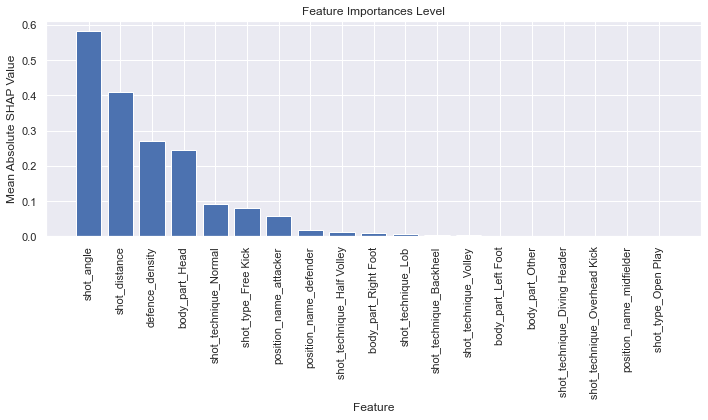

In [84]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(xg_model, x_adv, feature_names=adv_data.columns)

shap_values = explainer(xval_adv)

# Calculate the mean absolute SHAP values for each feature
mean_abs_shap = shap_values.abs.mean(axis=0)


# Sorting features by their mean absolute SHAP values
sorted_idx = mean_abs_shap.values.argsort()[::-1]

# Get the feature names for the sorted features
sorted_feature_names = [adv_data.columns[i] for i in sorted_idx]

sorted_mean_abs_shap = mean_abs_shap[sorted_idx]

# Create a bar chart of feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_feature_names)), sorted_mean_abs_shap.values)
plt.xticks(range(len(sorted_feature_names)), sorted_feature_names, rotation=90)
plt.xlabel('Feature')
plt.ylabel('Mean Absolute SHAP Value')
plt.title('Feature Importances Level')
plt.tight_layout()
plt.savefig('features importance level.jpg', bbox_inches='tight')
plt.show()

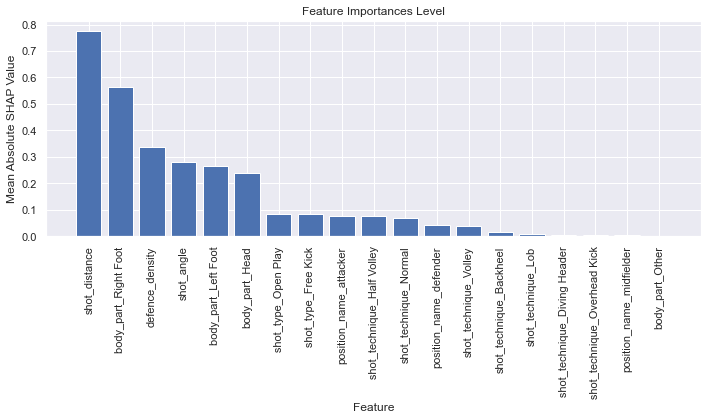

In [85]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(log_model, x_adv, feature_names=adv_data.columns)

shap_values = explainer(xval_adv)

# Calculate the mean absolute SHAP values for each feature
mean_abs_shap = shap_values.abs.mean(axis=0)


# Sorting features by their mean absolute SHAP values
sorted_idx = mean_abs_shap.values.argsort()[::-1]

# Get the feature names for the sorted features
sorted_feature_names = [adv_data.columns[i] for i in sorted_idx]

sorted_mean_abs_shap = mean_abs_shap[sorted_idx]

# Create a bar chart of feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_feature_names)), sorted_mean_abs_shap.values)
plt.xticks(range(len(sorted_feature_names)), sorted_feature_names, rotation=90)
plt.xlabel('Feature')
plt.ylabel('Mean Absolute SHAP Value')
plt.title('Feature Importances Level')
plt.tight_layout()
plt.savefig('features impact level lxg.jpg', bbox_inches='tight')
plt.show()

In [86]:
model_data = data4.copy()
model_data.dropna(inplace = True)
model_data.reset_index(drop = True, inplace = True)

In [87]:
def run_model(data, model):
    cols = ['shot_type','body_part', 'shot_technique', 'position_name', 'shot_distance','shot_angle', 'defence_density']
    categorical = cols[:4]
    numerical = cols[4:]
    x_adv, y_adv, advt_data = get_x_y(data, cols, numerical, categorical)
    xG = model.predict_proba(x_adv)[:,1]
    return xG

In [88]:
xgpred = run_model(model_data, xg_model)

C:\Users\Wales\anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [89]:
lrpred = run_model(model_data, log_model)

C:\Users\Wales\anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [90]:
model_data["Advance_xG"] = xgpred
model_data

,match_id,match_date,competition_id,season_id,location,under_pressure,event_id,stats_xg,loc_end,shot_outcome,...,player_name,position_name,shot_technique,shot_distance,shot_angle,frame_freezed_v2,defence_density,x_list,y_list,Advance_xG
0,9880,2018-04-14,11,1,"[101.0, 21.3]",False,16,0.008752,"[117.0, 39.7, 1.6]",No Goal,...,Gonçalo Manuel Ganchinho Guedes,midfielder,Normal,26.658770,12.341965,"[{'location': [95.6, 35.8], 'player': {'id': 5...",2,101.0,21.3,0.019242
1,9880,2018-04-14,11,1,"[103.9, 28.4]",False,16,0.053915,"[105.9, 29.7]",No Goal,...,Santiago Mina Lorenzo,attacker,Normal,19.843639,18.826717,"[{'location': [87.5, 30.1], 'player': {'id': 5...",1,103.9,28.4,0.077632
2,9880,2018-04-14,11,1,"[112.5, 26.0]",False,16,0.080842,"[116.6, 34.0, 0.2]",No Goal,...,Jordi Alba Ramos,defender,Normal,15.882380,14.250033,"[{'location': [117.1, 34.0], 'player': {'id': ...",1,112.5,26.0,0.061109
3,9880,2018-04-14,11,1,"[113.2, 46.0]",False,16,0.456472,"[120.0, 43.6, 0.2]",Goal,...,Luis Alberto Suárez Díaz,attacker,Normal,9.068627,39.394758,"[{'location': [104.5, 58.1], 'player': {'id': ...",1,113.2,46.0,0.368288
4,9880,2018-04-14,11,1,"[92.8, 32.9]",False,16,0.025283,"[117.9, 36.3, 0.5]",No Goal,...,Gonçalo Manuel Ganchinho Guedes,midfielder,Normal,28.111386,15.697815,"[{'location': [118.6, 38.5], 'player': {'id': ...",2,92.8,32.9,0.023554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33331,69161,2019-06-24,72,30,"[100.3, 52.5]",False,16,0.021892,"[101.1, 52.1]",No Goal,...,Lucía García Córdoba,midfielder,Normal,23.331095,16.609461,"[{'location': [101.6, 52.0], 'player': {'id': ...",1,100.3,52.5,0.042226
33332,69161,2019-06-24,72,30,"[96.3, 36.2]",False,16,0.038350,"[120.0, 39.1, 3.5]",No Goal,...,Rosemary Kathleen Lavelle,midfielder,Normal,24.002708,18.700592,"[{'location': [87.5, 56.0], 'player': {'id': 5...",3,96.3,36.2,0.038803
33333,69161,2019-06-24,72,30,"[98.5, 24.3]",False,16,0.025679,"[120.0, 47.1, 1.4]",No Goal,...,Samantha June Mewis,midfielder,Normal,26.622171,13.943962,"[{'location': [104.9, 30.6], 'player': {'id': ...",1,98.5,24.3,0.025972
33334,69161,2019-06-24,72,30,"[102.9, 54.6]",True,16,0.037896,"[120.0, 45.1, 5.2]",No Goal,...,Lucía García Córdoba,midfielder,Half Volley,22.484884,15.611898,"[{'location': [79.2, 21.1], 'player': {'id': 4...",1,102.9,54.6,0.022725


In [91]:
model_data["Advance_LxG"] = lrpred

In [92]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
def team_stats(team):
    x = model_data[model_data["competition_name"] == team]
    x.reset_index(drop=True, inplace=True)
    x_teams = x['team_name'].unique()
    x_clubs = {
        'Team name':[],
        'Total Shots': [],
        'Total Goals':[],
        'Stats_xg': [],
        'Shot quality':[],
        'Goal to shots': [],
        'Goals to statsxg':[],
        'Advance_xG': [],
        'Advance_LxG': [],
        'Stats_xg to xG':[],
        'Stats_xg to LxG':[]}
    for i in x_teams:
        curr_team = x[x["team_name"] == i].reset_index(drop=True)
        total_gls = np.sum([curr_team['shot_outcome'] == 'Goal'])
        total_xg = round(np.sum(curr_team['stats_xg']), 2)
        shot_quality = round(total_xg/len(curr_team), 2)
        gls_statsxg_ratio = round(total_gls/total_xg, 2)
        xG = round(np.sum(curr_team['Advance_xG']), 2)
        LxG = round(np.sum(curr_team['Advance_LxG']), 2)
        stats_xg_xg = round(total_xg/xG, 2)
        stats_xg_Lxg = round(total_xg/LxG, 2)
        gls_shots_ratio = round(total_gls/len(curr_team), 2)
        x_clubs['Team name'].append(i)
        x_clubs['Total Shots'].append(len(curr_team))
        x_clubs['Total Goals'].append(total_gls)
        x_clubs['Stats_xg'].append(total_xg)
        x_clubs['Shot quality'].append(shot_quality)
        x_clubs['Goal to shots'].append(gls_shots_ratio)
        x_clubs['Goals to statsxg'].append(gls_statsxg_ratio)
        x_clubs['Advance_xG'].append(xG)
        x_clubs['Advance_LxG'].append(LxG)
        x_clubs['Stats_xg to xG'].append(stats_xg_xg)
        x_clubs['Stats_xg to LxG'].append(stats_xg_Lxg)
    x_stats = pd.DataFrame.from_dict(x_clubs)
    return x_stats.sort_values(by='Total Goals', ascending=False).reset_index(drop = True)

In [93]:
team_stats("La Liga")

,Team name,Total Shots,Total Goals,Stats_xg,Shot quality,Goal to shots,Goals to statsxg,Advance_xG,Advance_LxG,Stats_xg to xG,Stats_xg to LxG
0,Barcelona,5820,932,708.38,0.12,0.16,1.32,771.37,769.17,0.92,0.92
1,Real Madrid,975,126,97.64,0.10,0.13,1.29,105.66,104.21,0.92,0.94
2,Atlético Madrid,652,71,64.05,0.10,0.11,1.11,66.97,64.89,0.96,0.99
3,Athletic Club,603,64,59.59,0.10,0.11,1.07,64.27,64.26,0.93,0.93
4,Real Sociedad,671,63,65.34,0.10,0.09,0.96,72.44,71.03,0.90,0.92
5,Sevilla,664,61,73.40,0.11,0.09,0.83,77.05,78.00,0.95,0.94
6,Valencia,588,61,62.13,0.11,0.10,0.98,64.88,65.17,0.96,0.95
7,Celta Vigo,571,60,61.34,0.11,0.11,0.98,62.50,62.61,0.98,0.98
8,Villarreal,500,54,48.88,0.10,0.11,1.10,49.14,47.18,0.99,1.04
9,Real Betis,542,52,49.87,0.09,0.10,1.04,53.29,52.62,0.94,0.95


In [94]:
team_stats("Ligue 1")

,Team name,Total Shots,Total Goals,Stats_xg,Shot quality,Goal to shots,Goals to statsxg,Advance_xG,Advance_LxG,Stats_xg to xG,Stats_xg to LxG
0,Paris Saint-Germain,865,126,109.40,0.13,0.15,1.15,112.44,108.04,0.97,1.01
1,Lille,52,5,6.15,0.12,0.10,0.81,7.43,7.52,0.83,0.82
2,Rennes,43,5,3.42,0.08,0.12,1.46,4.35,4.08,0.79,0.84
3,Lorient,42,5,5.20,0.12,0.12,0.96,5.01,4.78,1.04,1.09
4,Nantes,43,5,4.58,0.11,0.12,1.09,4.86,4.86,0.94,0.94
5,Troyes,25,4,2.26,0.09,0.16,1.77,2.72,2.83,0.83,0.80
6,Clermont Foot,28,4,4.06,0.14,0.14,0.99,4.14,4.29,0.98,0.95
7,Strasbourg,31,3,2.89,0.09,0.10,1.04,3.61,3.72,0.80,0.78
8,Montpellier,23,3,1.51,0.07,0.13,1.99,1.46,1.77,1.03,0.85
9,Lens,39,2,2.85,0.07,0.05,0.70,2.84,2.98,1.00,0.96


In [95]:
team_stats("Women's World Cup")

,Team name,Total Shots,Total Goals,Stats_xg,Shot quality,Goal to shots,Goals to statsxg,Advance_xG,Advance_LxG,Stats_xg to xG,Stats_xg to LxG
0,United States Women's,126,22,13.37,0.11,0.17,1.65,15.27,15.96,0.88,0.84
1,England Women's,85,12,9.78,0.12,0.14,1.23,10.40,10.22,0.94,0.96
2,Sweden Women's,104,11,9.68,0.09,0.11,1.14,11.79,12.24,0.82,0.79
3,Netherlands Women's,85,10,9.13,0.11,0.12,1.10,10.34,10.73,0.88,0.85
4,Germany Women's,76,9,9.24,0.12,0.12,0.97,9.85,10.16,0.94,0.91
5,Italy Women's,52,8,5.91,0.11,0.15,1.35,6.39,6.73,0.92,0.88
6,France Women's,89,8,6.90,0.08,0.09,1.16,7.69,8.05,0.90,0.86
7,Australia Women's,52,7,6.41,0.12,0.13,1.09,7.87,8.10,0.81,0.79
8,Scotland Women's,32,5,2.93,0.09,0.16,1.71,3.06,3.33,0.96,0.88
9,Brazil Women's,48,5,4.28,0.09,0.10,1.17,5.03,4.54,0.85,0.94


In [96]:
team_stats("FIFA World Cup")

,Team name,Total Shots,Total Goals,Stats_xg,Shot quality,Goal to shots,Goals to statsxg,Advance_xG,Advance_LxG,Stats_xg to xG,Stats_xg to LxG
0,France,179,23,16.70,0.09,0.13,1.38,18.89,18.23,0.88,0.92
1,England,154,21,16.70,0.11,0.14,1.26,15.79,16.52,1.06,1.01
2,Croatia,191,20,16.97,0.09,0.10,1.18,17.64,18.57,0.96,0.91
3,Argentina,152,17,14.83,0.10,0.11,1.15,17.65,17.06,0.84,0.87
4,Portugal,119,15,8.97,0.08,0.13,1.67,9.19,9.68,0.98,0.93
5,Belgium,142,15,15.64,0.11,0.11,0.96,17.15,17.97,0.91,0.87
6,Brazil,196,15,22.05,0.11,0.08,0.68,24.42,25.38,0.90,0.87
7,Spain,119,14,11.87,0.10,0.12,1.18,14.08,14.83,0.84,0.80
8,Japan,87,10,8.38,0.10,0.11,1.19,8.82,9.86,0.95,0.85
9,Switzerland,92,10,9.85,0.11,0.11,1.02,9.63,9.54,1.02,1.03


In [97]:
team_stats("Premier League")

,Team name,Total Shots,Total Goals,Stats_xg,Shot quality,Goal to shots,Goals to statsxg,Advance_xG,Advance_LxG,Stats_xg to xG,Stats_xg to LxG
0,Manchester City,606,66,58.29,0.10,0.11,1.13,62.34,62.55,0.94,0.93
1,Tottenham Hotspur,651,63,58.44,0.09,0.10,1.08,60.54,61.85,0.97,0.94
2,Arsenal,581,61,63.57,0.11,0.10,0.96,71.10,70.85,0.89,0.90
3,Liverpool,633,60,56.81,0.09,0.09,1.06,58.34,56.80,0.97,1.00
4,West Ham United,554,60,51.34,0.09,0.11,1.17,53.24,53.80,0.96,0.95
5,Leicester City,512,57,56.10,0.11,0.11,1.02,57.53,58.97,0.98,0.95
6,Southampton,523,54,51.09,0.10,0.10,1.06,54.85,54.89,0.93,0.93
7,Everton,493,52,46.70,0.09,0.11,1.11,50.75,50.27,0.92,0.93
8,Chelsea,530,51,49.66,0.09,0.10,1.03,52.83,54.10,0.94,0.92
9,Manchester United,428,43,39.85,0.09,0.10,1.08,42.77,42.70,0.93,0.93


In [98]:
team_stats("Champions League")

,Team name,Total Shots,Total Goals,Stats_xg,Shot quality,Goal to shots,Goals to statsxg,Advance_xG,Advance_LxG,Stats_xg to xG,Stats_xg to LxG
0,Real Madrid,77,11,7.66,0.10,0.14,1.44,8.05,8.35,0.95,0.92
1,Barcelona,39,6,4.20,0.11,0.15,1.43,4.31,4.54,0.97,0.93
2,Bayern Munich,56,3,5.78,0.10,0.05,0.52,5.33,5.67,1.08,1.02
3,Liverpool,27,2,1.85,0.07,0.07,1.08,2.23,2.23,0.83,0.83
4,Juventus,24,2,1.80,0.08,0.08,1.11,1.82,1.78,0.99,1.01
5,Atlético Madrid,29,2,2.82,0.10,0.07,0.71,2.59,2.71,1.09,1.04
6,Manchester United,4,1,0.30,0.08,0.25,3.33,0.44,0.37,0.68,0.81
7,Chelsea,9,1,0.29,0.03,0.11,3.45,0.29,0.29,1.00,1.00
8,Borussia Dortmund,12,0,0.73,0.06,0.00,0.00,0.72,0.81,1.01,0.90
9,Tottenham Hotspur,16,0,0.92,0.06,0.00,0.00,1.56,1.58,0.59,0.58


In [1]:
def pos_stats(position, team):
    x = model_data[model_data["competition_name"] == team]
    pos = x[x['position_name'] == position]
    print(f"Sum of advance_Lxg for {position} is {np.sum(pos['Advance_LxG'])}")
    print(f"Sum of advance_xg for {position} is {np.sum(pos['Advance_xG'])}")
    print(f"Total stats xG for {position} is {np.sum(pos['stats_xg'])}")
    print(f"Number of goals for {position} is {len(pos[pos['shot_outcome'] == 'Goal'])}")
    return None

In [100]:
pos_stats('defender', 'La Liga'),

print('----------------------------------------------------'),
pos_stats('midfielder', 'La Liga'),

print('----------------------------------------------------'),
pos_stats('attacker', 'La Liga')

Sum of advance_Lxg for defender is 200.6818090932872
Sum of advance_xg for defender is 213.77194213867188
Total stats xG for defender is 212.1064475312
Number of goals for defender is 204
----------------------------------------------------
Sum of advance_Lxg for midfielder is 326.81069399560823
Sum of advance_xg for midfielder is 334.7261047363281
Total stats xG for midfielder is 328.53613492500006
Number of goals for midfielder is 341
----------------------------------------------------
Sum of advance_Lxg for attacker is 1403.2290723389733
Sum of advance_xg for attacker is 1390.3935546875
Total stats xG for attacker is 1264.3063474665
Number of goals for attacker is 1483
